<a href="https://colab.research.google.com/github/ramonator00/bina/blob/main/BINA_Semesterarbeit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weightlifting Injury Detection

**Miriam Koppe, Ramona Koksa, Sahin Oyman, Sandra Vogel, Tim von Gunten**  
BINA FS26  
Fernfachhochschule Schweiz / Berner Fachhochschule

# Datensammlung
Im folgenden Abschnitt werden die strukturierten Daten gesammelt, bereinigt und modelliert. Weitere Details sind der beigefügten Dokumentation zu entnehmen.

In [22]:
! pip install dash

In [23]:
# =========================================================
# STANDARD LIBRARY
# =========================================================
import sqlite3
import pickle
from threading import Thread

# =========================================================
# DATA & VISUALIZATION
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# =========================================================
# GOOGLE COLAB
# =========================================================
from google.colab import drive, output

# =========================================================
# DASH
# =========================================================
from dash import Dash, dcc, html, Input, Output

# =========================================================
# MACHINE LEARNING
# =========================================================
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [24]:
# Google Drive unter dem Pfad '/content/drive' wird eingebunden um später die Daten zu lesen
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [25]:
import pandas as pd

# Definieren des vollständigen Pfads zur Datei
# Der Pfad wurde angepasst, da Dateien oft unter '/content/drive/MyDrive/' liegen.
file_path = '/content/drive/MyDrive/BINA/'

# CSV laden
df1 = pd.read_csv(file_path + "WL_injuries_MasterAthletes.csv")

# Excel laden
df2 = pd.read_excel(file_path + "High_Accuracy_Sport_Injury_Dataset.xlsx")

# Daten untersuchen
print("Dataset 1 Columns:")
print(df1.columns)
print("\nDataset 1 Info:")
print(df1.info())

print("\nDataset 2 Columns:")
print(df2.columns)
print("\nDataset 2 Info:")
print(df2.info())

Dataset 1 Columns:
Index(['id', 'sex', 'age', 'agegrp3', 'age_start', 'yrs_experience',
       'shoulder', 'knees', 'back', 'wrist', 'hips', 'OA', 'train_days',
       'train_session', 'train_warm', 'train_lift', 'train_strength',
       'train_supp', 'train_cool', 'pcoach', 'premote', 'pown', 'nutrition',
       'pa_power', 'pa_body', 'pa_cf', 'pa_ball', 'pa_fit', 'pa_endure',
       'pa_track', 'pa_ma', 'pa_yoga', 'sport0_power', 'sport0_body',
       'sport0_cf', 'sport0_ball', 'sport0_fit', 'sport0_endure',
       'sport0_track', 'sport0_ma', 'sport0_yoga', 'sport0_gym',
       'sport0_strength', 'sport0_impact'],
      dtype='object')

Dataset 1 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 44 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               976 non-null    int64 
 1   sex              976 non-null    object
 2   age              976 non-null    int64 
 3   

### Rohdaten in Sqlite Datenbank laden

In [26]:
conn = sqlite3.connect("injury_analysis.db")

df1.to_sql("wl_raw", conn, if_exists="replace", index=False)
df2.to_sql("sport_raw", conn, if_exists="replace", index=False)

df1 = pd.read_sql("SELECT * FROM wl_raw", conn)
df2 = pd.read_sql("SELECT * FROM sport_raw", conn)

### Targets erstellen

In [27]:
# Injury aus mehreren Spalten erkennen und harmonisieren
df1["injury"] = (df1[["shoulder", "knees", "back", "wrist"]].sum(axis=1) > 0).astype(int)

# Injury direkt aus dem zweiten Datenset übernehmen, da schon vorhanden
df2["injury"] = df2["Injury_Risk"]

### Spalten vereinheitlichen

In [28]:
df2_clean = df2.rename(columns={
    "Age": "age",
    "Gender": "gender",
    "Training_Frequency": "training_frequency",
    "Training_Duration": "training_duration",
    "Warmup_Time": "warmup_time",
    "Training_Intensity": "training_intensity",
    "Injury_History": "previous_injury",
    "Sleep_Hours": "sleep_hours",
    "Flexibility_Score": "flexibility_score",
    "Muscle_Asymmetry": "muscle_asymmetry",
    "Recovery_Time": "recovery_time",
    "Stress_Level": "stress_level"
})

# Gender fix (0/1 → m/f)
df2_clean["gender"] = df2_clean["gender"].map({0: "m", 1: "f"})

### Neues Schema modellieren

In [29]:
df1_clean = pd.DataFrame()

df1_clean["age"] = df1["age"]
df1_clean["gender"] = df1["sex"].str.lower()

df1_clean["training_frequency"] = df1["train_days"]
df1_clean["training_duration"] = df1["train_session"]
df1_clean["warmup_time"] = df1["train_warm"]

df1_clean["training_intensity"] = df1["train_lift"]
df1_clean["previous_injury"] = df1["OA"]

df1_clean["injury"] = df1["injury"]

# fehlende Features ergänzen
df1_clean["sleep_hours"] = np.nan
df1_clean["flexibility_score"] = np.nan
df1_clean["muscle_asymmetry"] = np.nan
df1_clean["recovery_time"] = np.nan
df1_clean["stress_level"] = np.nan

required_columns = df1_clean.columns

for col in required_columns:
    if col not in df2_clean.columns:
        df2_clean[col] = None

df2_clean = df2_clean[required_columns]

df_all = pd.concat([df1_clean, df2_clean], ignore_index=True)

# Datentypen bereinigen
df_all.columns = df_all.columns.str.lower().str.strip()

# Ergebnis prüfen
df_all

df_vis = df_all.copy()

# direkt in DB speichern
df_vis.to_sql("injury_data", conn, if_exists="replace", index=False)

1576

### Fehlende Features mittels KNN erweitern
Durch das Zusammenführen der Datensätze entstehen fehlende Werte (Missing Values, NaN),
da nicht alle Features in beiden Datensätzen vorhanden sind. Diese fehlenden Werte wurden mithilfe der K-Nearest Neighbors (KNN) Imputation geschätzt.


In [30]:
# 1. Features definieren
features_to_impute = [
    "sleep_hours",
    "flexibility_score",
    "muscle_asymmetry",
    "recovery_time",
    "stress_level",
    "training_intensity"
]

# 2. Datentypen sicherstellen
df_all[features_to_impute] = df_all[features_to_impute].apply(
    pd.to_numeric, errors="coerce"
)

# 3. Imputation flag
mask = df_all["sleep_hours"].isna()
df_all["imputed_flag"] = mask.astype(int)

# 4. Nur relevante Spalten imputen
imputer = KNNImputer(n_neighbors=5)

df_all[features_to_impute] = imputer.fit_transform(df_all[features_to_impute])

# 5. Check
print(df_all[features_to_impute].isna().sum())

# 6. Statistik
df_all.describe()

# Daten skalieren
scaler = StandardScaler()

features_to_scale = [
    "sleep_hours",
    "flexibility_score",
    "muscle_asymmetry",
    "recovery_time",
    "training_intensity",
    "training_frequency",
    "training_duration",
    "warmup_time",
    "stress_level"
]

df_all[features_to_scale] = scaler.fit_transform(df_all[features_to_scale])
print(df_all[features_to_scale].describe())

sleep_hours           0
flexibility_score     0
muscle_asymmetry      0
recovery_time         0
stress_level          0
training_intensity    0
dtype: int64
       sleep_hours  flexibility_score  muscle_asymmetry  recovery_time  \
count  1576.000000       1.576000e+03      1.576000e+03   1.576000e+03   
mean      0.000000       2.344430e-16     -1.983749e-16  -9.918744e-17   
std       1.000317       1.000317e+00      1.000317e+00   1.000317e+00   
min      -4.250415      -4.270544e+00     -2.868853e+00  -2.232297e+00   
25%      -0.780007      -3.476343e-01     -3.267105e-01  -7.941462e-01   
50%       0.169789       4.058444e-02      3.647523e-01  -3.778558e-02   
75%       0.717748       9.181489e-01      5.071123e-01   6.440042e-01   
max       3.968972       4.430443e+00      4.452518e+00   2.508273e+00   

       training_intensity  training_frequency  training_duration  \
count        1.576000e+03        1.576000e+03        1576.000000   
mean        -1.803408e-16        5.41022

### Daten in Sqlite Datenbank laden
Damit später eine bessere Daten Analyse erstellt werden kann, werden die Daten in eine Sqlite Datenbank geladen.

In [31]:
# Harmonisierte Daten laden
df_all.to_sql("athlete_data", conn, if_exists="replace", index=False)

pd.read_sql("SELECT * FROM athlete_data LIMIT 5;", conn)

,age,gender,training_frequency,training_duration,warmup_time,training_intensity,previous_injury,injury,sleep_hours,flexibility_score,muscle_asymmetry,recovery_time,stress_level,imputed_flag
0,42,m,-0.491814,-0.785000,-0.476794,-0.224316,1,1,0.717748,0.040584,0.364752,0.644004,0.829822,1
1,54,m,-0.491814,-0.760749,-0.653641,0.385099,1,1,-0.780007,0.073162,0.507112,-0.037786,-0.555664,1
2,40,m,0.962405,-0.712247,-0.476794,-0.224316,1,1,0.717748,0.040584,0.364752,0.644004,0.829822,1
3,37,m,0.235296,-0.736498,-0.476794,-0.833730,1,1,0.169789,0.928329,0.080032,-0.794146,-0.258774,1
4,48,f,-0.491814,-0.760749,-0.653641,-0.224316,1,0,0.717748,0.040584,0.364752,0.644004,0.829822,1


In [32]:
pd.read_sql("""
SELECT gender, AVG(injury) as injury_rate
FROM athlete_data
GROUP BY gender
""", conn)

,gender,injury_rate
0,f,0.452880
1,m,0.546798


# Datenanalyse

### Using AI Tools to analyze data

In [33]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Neural Net": MLPClassifier(max_iter=500)
}

df_model = pd.read_sql("SELECT * FROM athlete_data", conn)

# previous_injury binarisieren
df_model["previous_injury"] = (df_model["previous_injury"] > 0).astype(int)

# gender fix
df_model["gender"] = df_model["gender"].map({"m": 0, "f": 1})

# optional: prüfen
print(df_model["gender"].unique())

# unnötige Spalte entfernen
if "imputed_flag" in df_model.columns:
    df_model = df_model.drop(columns=["imputed_flag"])

X = df_model.drop(columns=["injury"])
y = df_model["injury"]

results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="f1")
    results.append((name, scores.mean()))

df_results = pd.DataFrame(results, columns=["Model", "F1 Score"])
print(df_results.sort_values(by="F1 Score", ascending=False))

[0 1]
                 Model  F1 Score
5    Gradient Boosting  0.678529
0        Random Forest  0.676440
3                  SVM  0.632943
6           Neural Net  0.622574
4          Naive Bayes  0.607382
2  Logistic Regression  0.567668
1                  KNN  0.539282


[0 1]
              precision    recall  f1-score   support

   No Injury       0.73      0.47      0.57       153
      Injury       0.63      0.83      0.72       163

    accuracy                           0.66       316
   macro avg       0.68      0.65      0.64       316
weighted avg       0.68      0.66      0.65       316



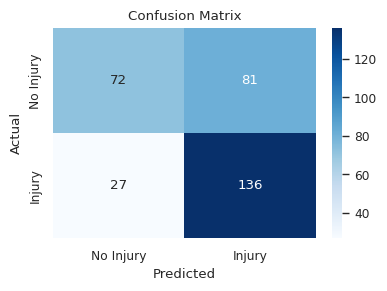

In [34]:
df_model = pd.read_sql("SELECT * FROM athlete_data", conn)

# previous_injury binarisieren
df_model["previous_injury"] = (df_model["previous_injury"] > 0).astype(int)

# gender fix
df_model["gender"] = df_model["gender"].map({"m": 0, "f": 1})

# optional: prüfen
print(df_model["gender"].unique())

# unnötige Spalte entfernen
if "imputed_flag" in df_model.columns:
    df_model = df_model.drop(columns=["imputed_flag"])

X = df_model.drop(columns=["injury"])
y = df_model["injury"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Injury", "Injury"]))

cm = confusion_matrix(y_test, y_pred)

labels = ["No Injury", "Injury"]

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# Model speichern
with open("injury_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Feature Reihenfolge speichern
feature_columns = X.columns.tolist()

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

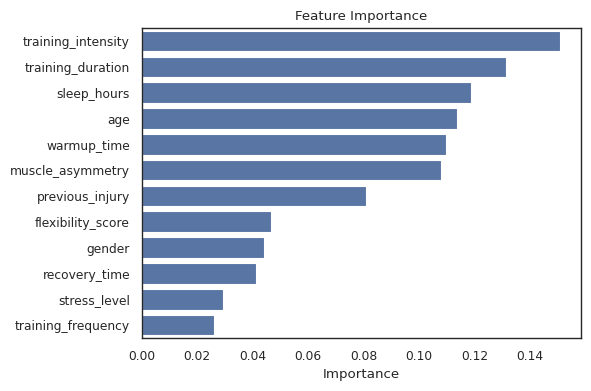

In [35]:
importance = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("")

plt.tight_layout()
plt.show()

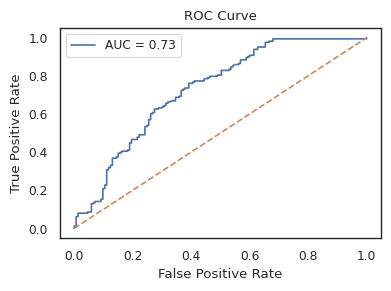

In [36]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(4,3))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
# =========================================================
# LOAD DATA FROM SQLITE
# =========================================================
conn = sqlite3.connect("injury_analysis.db")
df = pd.read_sql("SELECT * FROM injury_data", conn)

# Labels
df["gender_label"] = df["gender"].map({"m": "Male", "f": "Female"}).fillna("Unknown")
df["injury_label"] = df["injury"].map({1: "Injury", 0: "No Injury"})

if "age" in df.columns:
    df["age_group"] = pd.cut(
        df["age"],
        bins=[0, 25, 35, 45, 100],
        labels=["<25", "25-35", "35-45", "45+"]
    )

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

default_x = "training_intensity" if "training_intensity" in numeric_cols else numeric_cols[0]
default_y = "load_score" if "load_score" in numeric_cols else numeric_cols[1]

# =========================================================
# LOAD MODEL (für Prediction Tab)
# =========================================================
with open("injury_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)

# =========================================================
# DASH APP
# =========================================================
app = Dash(__name__)

app.layout = html.Div([

    html.H2("Injury Analytics Dashboard"),

    dcc.Tabs([

        # =========================================================
        # TAB 1: DEIN DASHBOARD (UNVERÄNDERT)
        # =========================================================
        dcc.Tab(label="Dashboard", children=[

            html.Div([

                # HEADER
                html.Div([
                    html.P("Interactive exploration of injury risk factors",
                           style={"color": "#6c757d"})
                ], style={"marginBottom": "20px"}),

                # FILTER PANEL
                html.Div([

                    html.Div([
                        html.Label("Gender"),
                        dcc.Dropdown(
                            id="gender-filter",
                            options=[{"label": g, "value": g} for g in df["gender_label"].unique()],
                            value=list(df["gender_label"].unique()),
                            multi=True
                        )
                    ], style={"width": "20%", "display": "inline-block", "padding": "5px"}),

                    html.Div([
                        html.Label("Age Group"),
                        dcc.Dropdown(
                            id="age-filter",
                            options=[{"label": a, "value": a} for a in df["age_group"].dropna().unique()],
                            value=list(df["age_group"].dropna().unique()),
                            multi=True
                        )
                    ], style={"width": "20%", "display": "inline-block", "padding": "5px"}),

                    html.Div([
                        html.Label("Plot Type"),
                        dcc.Dropdown(
                            id="plot-type",
                            options=[
                                {"label": "Scatter", "value": "scatter"},
                                {"label": "Histogram", "value": "hist"},
                                {"label": "Box", "value": "box"},
                                {"label": "Violin", "value": "violin"},
                                {"label": "Density", "value": "density"},
                                {"label": "Correlation Heatmap", "value": "corr"},
                                {"label": "Line", "value": "line"},
                            ],
                            value="scatter"
                        )
                    ], style={"width": "20%", "display": "inline-block", "padding": "5px"}),

                    html.Div([
                        html.Label("X Axis"),
                        dcc.Dropdown(
                            id="x-axis",
                            options=[{"label": c, "value": c} for c in numeric_cols],
                            value=default_x
                        )
                    ], style={"width": "20%", "display": "inline-block", "padding": "5px"}),

                    html.Div([
                        html.Label("Y Axis"),
                        dcc.Dropdown(
                            id="y-axis",
                            options=[{"label": c, "value": c} for c in numeric_cols],
                            value=default_y
                        )
                    ], style={"width": "20%", "display": "inline-block", "padding": "5px"}),

                ], style={
                    "backgroundColor": "white",
                    "padding": "15px",
                    "borderRadius": "12px",
                    "boxShadow": "0px 4px 12px rgba(0,0,0,0.05)",
                    "marginBottom": "20px"
                }),

                # FEATURE SELECT
                html.Div([
                    html.Label("Features"),
                    dcc.Dropdown(
                        id="features",
                        options=[{"label": c, "value": c} for c in numeric_cols],
                        value=numeric_cols[:5],
                        multi=True
                    )
                ], style={
                    "backgroundColor": "white",
                    "padding": "15px",
                    "borderRadius": "12px",
                    "boxShadow": "0px 4px 12px rgba(0,0,0,0.05)",
                    "marginBottom": "20px"
                }),

                html.Div(id="kpis", style={"display": "flex", "gap": "15px", "marginBottom": "20px"}),
                html.Div(id="plots")

            ], style={
                "maxWidth": "1300px",
                "margin": "auto",
                "padding": "20px",
                "backgroundColor": "#f5f7fa",
                "fontFamily": "Arial"
            })

        ]),

        # =========================================================
        # TAB 2: PREDICTION
        # =========================================================
        dcc.Tab(label="Prediction", children=[

            html.Div([

                html.H3("Injury Risk Prediction", style={"marginBottom": "20px"}),

                # INPUT CARD
                html.Div([

                    html.Div([
                        html.Label("Age"),
                        dcc.Slider(
                            id="age-input",
                            min=15, max=70, step=1, value=30,
                            marks={20: "20", 40: "40", 60: "60"}
                        )
                    ], style={"marginBottom": "20px"}),

                    html.Div([
                        html.Label("Training Intensity"),
                        dcc.Slider(
                            id="intensity-input",
                            min=1, max=5, step=1, value=3,
                            marks={1: "1", 3: "3", 5: "5"}
                        )
                    ], style={"marginBottom": "20px"}),

                    html.Div([
                        html.Label("Training Frequency"),
                        dcc.Input(
                            id="frequency-input",
                            type="number",
                            value=3,
                            style={"width": "100%"}
                        )
                    ], style={"marginBottom": "20px"}),

                    html.Div([
                        html.Label("Sleep Hours"),
                        dcc.Slider(
                            id="sleep-input",
                            min=3, max=10, step=0.5, value=7,
                            marks={4: "4h", 7: "7h", 9: "9h"}
                        )
                    ], style={"marginBottom": "20px"}),

                    html.Div([
                        html.Label("Stress Level"),
                        dcc.Slider(
                            id="stress-input",
                            min=1, max=5, step=1, value=3,
                            marks={1: "Low", 3: "Mid", 5: "High"}
                        )
                    ], style={"marginBottom": "20px"}),

                ], style={
                    "backgroundColor": "white",
                    "padding": "20px",
                    "borderRadius": "12px",
                    "boxShadow": "0px 4px 12px rgba(0,0,0,0.05)",
                    "marginBottom": "20px"
                }),

                # BUTTON + RESULT
                html.Div([

                    html.Button(
                        "Run Prediction",
                        id="predict-btn",
                        style={
                            "padding": "10px 20px",
                            "backgroundColor": "#4C78A8",
                            "color": "white",
                            "border": "none",
                            "borderRadius": "6px",
                            "cursor": "pointer"
                        }
                    ),

html.Div(id="prediction-output", style={
    "marginTop": "20px",
    "fontSize": "22px",
    "fontWeight": "600"
}),

html.Div(id="feature-importance", style={
    "marginTop": "30px"
})

                ], style={"textAlign": "center"})

            ], style={
                "maxWidth": "700px",
                "margin": "auto",
                "padding": "20px"
            })

        ])

    ])

])

# =========================================================
# DASHBOARD CALLBACK (UNVERÄNDERT)
# =========================================================
@app.callback(
    Output("kpis", "children"),
    Output("plots", "children"),
    Input("gender-filter", "value"),
    Input("age-filter", "value"),
    Input("plot-type", "value"),
    Input("x-axis", "value"),
    Input("y-axis", "value"),
    Input("features", "value"),
)
def update_dashboard(genders, ages, plot_type, x, y, features):

    dff = df[
        (df["gender_label"].isin(genders)) &
        (df["age_group"].isin(ages))
    ].copy()

    if len(dff) > 1000:
        dff = dff.sample(1000, random_state=42)

    if dff.empty:
        return [], html.Div("No data available")

    def card(title, value):
        return html.Div([
            html.Div(title, style={"fontSize": "12px", "color": "#6c757d"}),
            html.Div(value, style={"fontSize": "20px", "fontWeight": "600"})
        ], style={
            "backgroundColor": "white",
            "padding": "15px",
            "borderRadius": "10px",
            "boxShadow": "0px 4px 12px rgba(0,0,0,0.05)",
            "minWidth": "120px"
        })

    kpis = [
        card("Rows", f"{len(dff):,}"),
        card("Injury Rate", f"{dff['injury'].mean()*100:.1f}%"),
        card("Avg X", f"{dff[x].mean():.2f}" if x in dff else "-"),
        card("Avg Y", f"{dff[y].mean():.2f}" if y in dff else "-"),
    ]

    if plot_type == "scatter":
        fig = px.scatter(dff, x=x, y=y, color="injury_label", symbol="gender_label")

    elif plot_type == "hist":
        fig = px.histogram(dff, x=x, color="injury_label")

    elif plot_type == "box":
        fig = px.box(dff, x="injury_label", y=x)

    elif plot_type == "violin":
        fig = px.violin(dff, x="injury_label", y=x)

    elif plot_type == "density":
        fig = px.density_contour(dff, x=x, y=y)

    elif plot_type == "line":
        fig = px.line(dff.sort_values(x), x=x, y=y)

    elif plot_type == "corr":
        fig = px.imshow(dff[features].corr())

    fig.update_layout(template="plotly_white", height=600)

    return kpis, dcc.Graph(figure=fig)

@app.callback(
    Output("prediction-output", "children"),
    Output("feature-importance", "children"),
    Input("predict-btn", "n_clicks"),
    Input("age-input", "value"),
    Input("intensity-input", "value"),
    Input("frequency-input", "value"),
    Input("sleep-input", "value"),
    Input("stress-input", "value"),
)

def predict(n, age, intensity, frequency, sleep, stress):

    if not n:
        return "", ""

    # =====================
    # BASELINE (WICHTIG)
    # =====================
    defaults = df.mean(numeric_only=True).to_dict()

    # =====================
    # USER INPUT
    # =====================
    defaults.update({
        "age": age,
        "training_intensity": intensity,
        "training_frequency": frequency,
        "sleep_hours": sleep,
        "stress_level": stress,
        "load_score": intensity * frequency if intensity and frequency else 0
    })

    if "gender" in feature_columns:
        defaults["gender"] = 0

    # =====================
    # MODEL INPUT
    # =====================
    input_df = pd.DataFrame([defaults])
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    # =====================
    # PREDICTION
    # =====================
    prob = model.predict_proba(input_df)[0][1]

    # =====================
    # FEATURE IMPORTANCE
    # =====================
    importance = pd.Series(
        model.feature_importances_,
        index=feature_columns
    ).sort_values(ascending=False).head(8)

    fig = px.bar(
        importance,
        x=importance.values,
        y=importance.index,
        orientation="h"
    )

    fig.update_layout(
        template="plotly_white",
        height=400,
        margin=dict(l=40, r=20, t=30, b=30)
    )

    return (
        f"Injury Risk: {prob*100:.1f}%",
        dcc.Graph(figure=fig)
    )

# =========================================================
# RUN
# =========================================================
def run_dash():
    app.run(host="0.0.0.0", port=8050, debug=False)

thread = Thread(target=run_dash)
thread.daemon = True
thread.start()

output.serve_kernel_port_as_window(8050)

Dash is running on http://0.0.0.0:8050/

Try `serve_kernel_port_as_iframe` instead. 


INFO:dash.dash:Dash is running on http://0.0.0.0:8050/



 * Serving Flask app '__main__'


<IPython.core.display.Javascript object>

 * Debug mode: off


Address already in use
Port 8050 is in use by another program. Either identify and stop that program, or start the server with a different port.
